In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Generate data

In [28]:
X_train = np.linspace(-1,1,20)

In [29]:
y_train = np.array([
                    -0.6561, -0.3099, -0.59035, -0.50855,
                    -0.285, -0.2443, -0.02445, 0.00135,
                    -0.2006, 0.07475, -0.1422,
                    0.5524, 0.23115, 0.20835,
                    0.4211, 0.60485,
                    0.3152, 0.4128, -0.1875, 0.1284
                    ])

In [30]:
X_test = np.linspace(-1,1,20)

In [31]:
y_test = np.array([
                    -0.69415, -0.451, -0.43005, -0.4484, -0.1475,
                    -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
                    0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
                    0.3639, 0.5536, 0.3365, 0.50705, 0.33435
                    ])

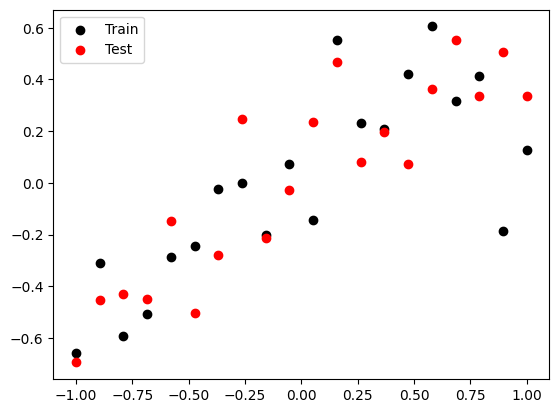

In [32]:
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.legend()
plt.show()

In [42]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)

c:\DataScience\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [44]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
history = model.fit(X_train, y_train, epochs=500, validation_data=(X_test,y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.1348 - mse: 0.1348 - val_loss: 0.0476 - val_mse: 0.0476
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0719 - mse: 0.0719 - val_loss: 0.0334 - val_mse: 0.0334
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0579 - mse: 0.0579 - val_loss: 0.0404 - val_mse: 0.0404
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0556 - mse: 0.0556 - val_loss: 0.0430 - val_mse: 0.0430
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0540 - mse: 0.0540 - val_loss: 0.0317 - val_mse: 0.0317
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0435 - mse: 0.0435 - val_loss: 0.0306 - val_mse: 0.0306
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0444 - mse: 0.0444 - val_loss: 0.0324 - val_mse: 0.0324
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0447 - mse: 0.0447 - val_loss: 0.0313 - val_mse: 0.0313
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0388 - 

In [45]:
_,train_mse = model.evaluate(X_train, y_train, verbose=0)
_,test_mse = model.evaluate(X_test, y_test, verbose=0)

print('train_mse{}  test_mse{}'.format(train_mse, test_mse))

train_mse0.006244634743779898  test_mse0.06401846557855606


In [46]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


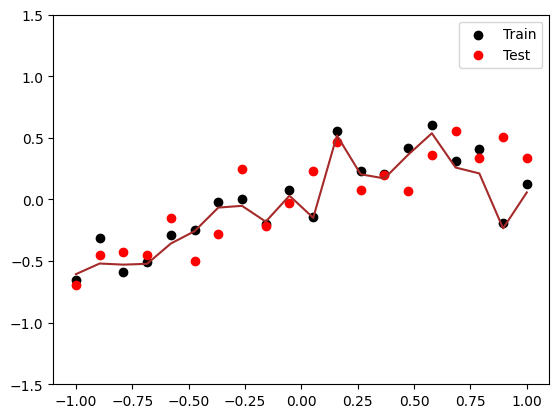

In [47]:
plt.Figure()
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.plot(X_test, y_pred, c='brown'
         )
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

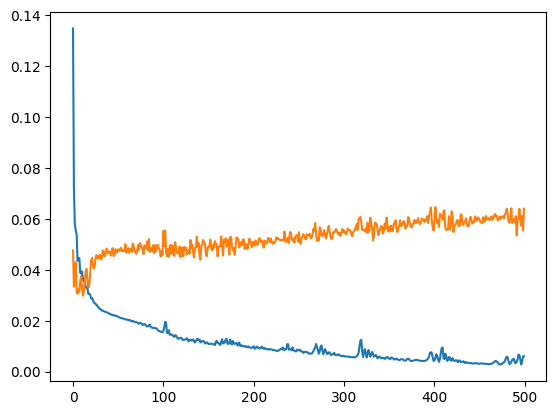

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Droupout model 

In [60]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)

In [61]:
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [62]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
history = model.fit(X_train, y_train, epochs=500, validation_data=(X_test,y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1332 - mse: 0.1332 - val_loss: 0.0428 - val_mse: 0.0428
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0681 - mse: 0.0681 - val_loss: 0.0415 - val_mse: 0.0415
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0887 - mse: 0.0887 - val_loss: 0.0335 - val_mse: 0.0335
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0571 - mse: 0.0571 - val_loss: 0.0279 - val_mse: 0.0279
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0613 - mse: 0.0613 - val_loss: 0.0295 - val_mse: 0.0295
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0698 - mse: 0.0698 - val_loss: 0.0315 - val_mse: 0.0315
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0879 - mse: 0.0879 - val_loss: 0.0293 - val_mse: 0.0293
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0852 - mse: 0.0852 - val_loss: 0.0333 - val_mse: 0.0333
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0596 - mse: 0.

In [63]:
_,train_mse = model.evaluate(X_train, y_train, verbose=0)
_,test_mse = model.evaluate(X_test, y_test, verbose=0)

print('train_mse{}  test_mse{}'.format(train_mse, test_mse))

train_mse0.022932754829525948  test_mse0.043053001165390015


In [64]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


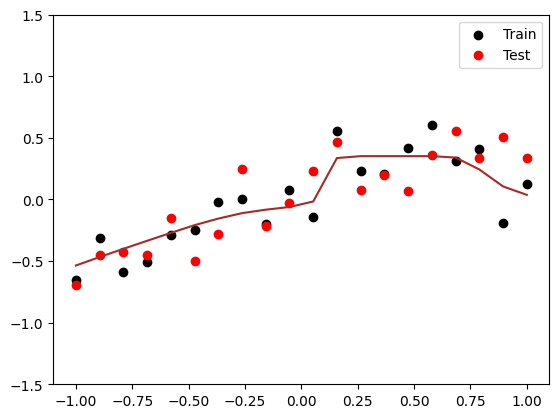

In [65]:
plt.Figure()
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')
plt.plot(X_test, y_pred, c='brown'
         )
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

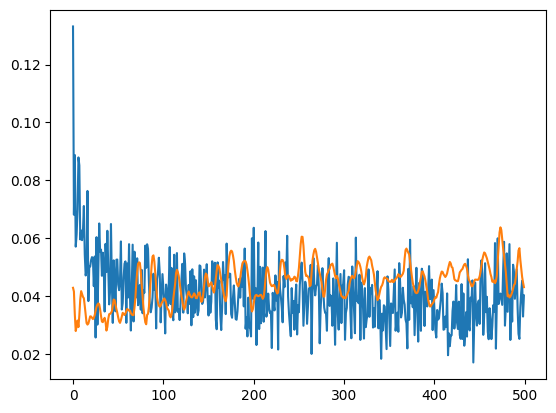

In [66]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])